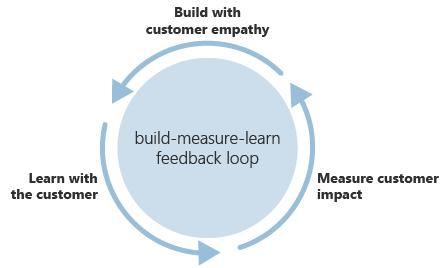

In [9]:
from IPython.display import display, Image as IPImage
from PIL import Image
import base64
from io import BytesIO

def convert_to_base64(pil_image):  # Fixed parameter naming
    # 이미지를 바이트 스트림으로 변환
    buffered = BytesIO()  # Corrected to call BytesIO() function
    # 이미지를 JPEG 형식으로 저장
    pil_image.save(buffered, format="JPEG")  # Fixed spacing
    # 필요에 따라 형식 변경 가능
    # 바이트 데이터를 base64로 인코딩하고 문자열로 변환
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")  # Fixed spacing and added missing dot
    return img_str
# 이미지 파일 경로 지정
file_path = "image.png"
# PIL을 사용하여 이미지 파일 열기
pil_image = Image.open(file_path)
# 이미지를 base64 문자열로 변환
image_b64 = convert_to_base64(pil_image)
display(IPImage(data=base64.b64decode(image_b64)))

In [11]:
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

gemma = ChatOllama(model="gemma3:12b")

def prompt_func(data):
    text = data["text"]
    image = data ["image"]

    image_part = {
    "type": "image_url",
    "image_url": f"data:image/jpeg;base64,{image}",
    }

    content_parts = []

    text_part = {"type": "text", "text": text}

    content_parts.append(image_part)
    content_parts.append(text_part)

    return [HumanMessage(content=content_parts)]

chain = prompt_func | gemma | StrOutputParser()
result = []

for chunk in chain.stream(
    {"text": "Describe the image in detail in korean.", "image": image_b64}):
    result.append(chunk)
    print(chunk, end="", flush=True)

Okay, here's a detailed description of the image in Korean:

**이미지 설명 (Image Description)**

이 이미지는 "build-measure-learn" 피드백 루프를 나타내는 원형 다이어그램입니다. 배경은 밝은 회색이며, 중앙에는 연한 파란색 원이 그려져 있습니다. 이 원 안에는 "build-measure-learn feedback loop"라는 텍스트가 영어로 적혀 있습니다.

원 주변에는 세 개의 화살표가 시계 방향으로 배치되어 있습니다. 각 화살표는 원의 특정 지점을 가리키고, 그 지점에는 다음과 같은 텍스트가 영어로 적혀 있습니다:

*   **"Build with customer empathy"** (고객 공감으로 구축하기) - 원의 오른쪽 상단 부분에 위치
*   **"Measure customer impact"** (고객 영향 측정하기) - 원의 오른쪽 하단 부분에 위치
*   **"Learn with the customer"** (고객과 함께 배우기) - 원의 왼쪽 하단 부분에 위치

이 다이어그램은 고객 중심의 제품 개발 또는 서비스 개선 프로세스를 시각적으로 보여주는 것으로 보입니다. 각 단계가 순환적으로 연결되어 고객의 피드백을 반영하고 지속적인 개선을 추구하는 과정을 강조합니다.

**Translation Notes:**

*   I'm aiming for a clear and descriptive explanation, suitable for someone who understands basic English terminology related to product development.
*   The Korean phrases are provided in parentheses to help with understanding.



Let me know if you'd like any adjustments or further details!

In [12]:
from IPython.display import Markdown
Markdown(''.join(result))

Okay, here's a detailed description of the image in Korean:

**이미지 설명 (Image Description)**

이 이미지는 "build-measure-learn" 피드백 루프를 나타내는 원형 다이어그램입니다. 배경은 밝은 회색이며, 중앙에는 연한 파란색 원이 그려져 있습니다. 이 원 안에는 "build-measure-learn feedback loop"라는 텍스트가 영어로 적혀 있습니다.

원 주변에는 세 개의 화살표가 시계 방향으로 배치되어 있습니다. 각 화살표는 원의 특정 지점을 가리키고, 그 지점에는 다음과 같은 텍스트가 영어로 적혀 있습니다:

*   **"Build with customer empathy"** (고객 공감으로 구축하기) - 원의 오른쪽 상단 부분에 위치
*   **"Measure customer impact"** (고객 영향 측정하기) - 원의 오른쪽 하단 부분에 위치
*   **"Learn with the customer"** (고객과 함께 배우기) - 원의 왼쪽 하단 부분에 위치

이 다이어그램은 고객 중심의 제품 개발 또는 서비스 개선 프로세스를 시각적으로 보여주는 것으로 보입니다. 각 단계가 순환적으로 연결되어 고객의 피드백을 반영하고 지속적인 개선을 추구하는 과정을 강조합니다.

**Translation Notes:**

*   I'm aiming for a clear and descriptive explanation, suitable for someone who understands basic English terminology related to product development.
*   The Korean phrases are provided in parentheses to help with understanding.



Let me know if you'd like any adjustments or further details!

In [16]:
import ollama

response = ollama.chat(
    model= 'gemma3:12b',
    messages=[{'role': 'user', 'content': 'What is the weather in Toronto?'}],

    tools=[{
        "type": "function",
        "function": {
            "name": "get_current_weather",
            'description': 'Get the current weather for a city',
            'parameters': {
                'type': 'object',
                'properties': {
                    'city': {
                        'type': 'string',
                        'description': 'The name of the city',
                    },
                },
                'required': ['city'],
            }
        }
    }]
)

ResponseError: registry.ollama.ai/library/gemma3:12b does not support tools (status code: 400)